In [1]:
# imports and settings
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
import seaborn as sns
import nglview as nv                            # for visualisation
from MDAnalysis.analysis.align import alignto   # for aligning structures
from MDAnalysis.analysis.pca import PCA         # for PCA
from Bio.PDB import PDBParser
from Bio.PDB.DSSP import DSSP                   # for secondary structure selection
from Bio.PDB.SASA import ShrakeRupley           # for SASA calculation
from IPython.display import display             # for data frame display
from multiprocessing import Pool                # for multiprocessing
from tqdm import tqdm                           # for progress bars
 
# surpress warnings
warnings.filterwarnings(action='ignore', module='matplotlib')
warnings.filterwarnings(action='ignore', module='mdanalysis')
warnings.filterwarnings('ignore')

# pandas settings
pd.set_option('display.max_colwidth', None)

############################################################################################################

# base directories
base_directory = "/biggin/b212/bioc1781/Projects/KDELR/red-msa/" #"/biggin/b212/bioc1781/Projects/KDELR/red-msa/"  #"/biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/"
structure_directory = base_directory + "ensemble/" # directory with the AF2 ensemble, cannot be the same as base directory

# settings
selection_for_writeout  = "protein and name CA"  # useful if you want all the outputs to have a specific selection
conserved_residues      = "(resid 1 or resid 2 or resid 4 or resid 5 or resid 12 or resid 29 or resid 31 or resid 33 or resid 37 or resid 40 or resid 47 or resid 48 or resid 59 or resid 86 or resid 91 or resid 120 or resid 125 or resid 127 or resid 133 or resid 134 or resid 150 or resid 151 or resid 159 or resid 165 or resid 166 or resid 187 or resid 193 or resid 194 or resid 196 or resid 198 or resid 210 or resid 211)"
excluded_residues       = None                   # e.g. PepT2 soluble domain: resid 363-565
do_not_excluse_residues = "((resid 208-212) and resname LYS)" 
resid_offset            = 0                      # useful if there is a mismatch between the residue numbering in e.g. reference pdbs or the ensemble pdbs

# structure filtering   
msa_depths = ['8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024']
thresh_rmsd             = 10                # threshold for discarding structures based on RMSD
thresh_pLDDT            = 82                # threshold for discarding structures based on pLDDT
thresh_sasa_coeff       = 100               # multiple of highest sasa of the reference structure above which structures are discarded

# OPTIONAL - Define some useful MDA selection tokens selections here
OF_gate_1 = 'resid 1-10'
OF_gate_2 = 'resid 10-20'
IF_gate_1 = 'resid 20-30'
IF_gate_2 = 'resid 30-40'
TMx  = '(resid 141) and name CA'
TMy  = '(resid 201) and name CA'
TMy  = '(resid 153) and name CA'

# OPTIONAL - Distances to evaluate for inclusion in the ensemble dataframe
distances_to_evaluate = {'TM_deflection': (TMx, TMy)}

#distances_to_evaluate = {'OF_gate': (OF_gate_1, OF_gate_2), 
#                         'IF_gate': (IF_gate_1, IF_gate_2)}

# for plotting
plot_variable_1 = 'PC1'   
plot_variable_2 = 'PC2'
plot_variable_3 = 'sasa'

# analysis  
num_processes   = 12                # CPU cores to use for multiprocessing
n_pcs           = 3                 # number of principal components to keep in PCA

# monte carlo   
#mc_temp         = 500               # monte carlo temperature
#mc_wf_sasa      = 0                 # monte carlo energy function weight factor for SASA (check if this should be -ve, depends on order of subtraction and matrix indexing)
#mc_n_runs       = 1                 # number of monte carlo runs
mc_n_bins       = 16                # so mc_n_bins is the total number of bins (because of reference structures and zero indexing)
collective_variable = 'PC1'         # collective_variable to bin for path finding
start_from_endstates = False

# OPTIONAL - User speficied "reference" or template structures (i.e. from experiment)
use_reference_structures = False
user_specified_structures = [base_directory + "KDELR_7cdf6_weblogo.pdb"]

reference_pdb = base_directory + "KDELR_7cdf6_weblogo.pdb"
u = mda.Universe(reference_pdb) # reference universe

# template should be a pdb from e.g. an unbiased simulation you've run before
# containing everything in the simualtion box, protein, lipids, water etc. 
# if you have a working topolgy for this system, you can re-use it here
template_pdb_for_umbrella_sampling = (base_directory + 'template_holo+lig.pdb')

############################################################################################################

os.environ["OMP_NUM_THREADS"] = str(num_processes)

if use_reference_structures:
    for ref_structure in user_specified_structures:
        if not os.path.exists(ref_structure):
            raise FileNotFoundError(f"Reference structure {ref_structure} not found")
        else:
            print(f"Using reference structure {ref_structure}")
            u = mda.Universe(ref_structure)
            u.atoms.residues.resids -= resid_offset

# Create a colormap
cmap = plt.cm.get_cmap('tab20c')

# Create a color cycle from the colormap
colors = cmap(np.linspace(0, 1, 10))  # Sample 10 colors from the colormap

# Set the default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


In [2]:
# Structure retrieval - user specific - do whatever you need here to get a dictionary of structures and their associated pLDDT values

# # ONLY NEED TO RUN ONCE 
# # copy structures from outputs to ensemble
# msa_depths = ['32-64', '64-128', '128-256', '256-512', '512-1024']
# 
# for msa in msa_depths:
#     structures_msa = [f for f in os.listdir(base_directory + 'output_' + msa) if f.endswith('.pdb')]
#     for structure in structures_msa:
#         # copy all the pdb files with "_relaxed_" in the name to the structure directory
#         if "_relaxed_" in structure:
#             # get the rank of the strcuture (last thing before the file extension)
#             rank = 'rank_' + structure.split('_')[structure.split('_').index('rank')+1]
#             os.system('cp ' + base_directory + 'output_' + msa + '/' + structure + ' ' + structure_directory + '/msa-' + msa + '_' + rank + '.pdb')
# 
# # get list of all files in structure directory directory with the pdb extension
# structures = [f for f in os.listdir(structure_directory) if f.endswith('.pdb')]
# structures.sort()


In [3]:
# Apply pLDDT filters and define an atom group for the PCA and RMSD calculations

from ensemblr.smart_selector import generate_selection_token

# copy file called "log.txt" from each output directory to the structure directory and name it after the msa
for msa in msa_depths:
    # logfile is a file in directory output_msa called log.txt
    structures_msa = [f for f in os.listdir(base_directory + 'output_' + msa) if f.endswith('log.txt')]
    for logfile in structures_msa:
            os.system('cp ' + base_directory + 'output_' + msa + '/' + logfile + ' ' + structure_directory + '/' + msa + '_log.txt')

# associate structures with pLDDT values
structure_and_pLDDT = {}
for msa in msa_depths:
    structures_msa = [f for f in os.listdir(structure_directory) if f.endswith('.pdb') and msa in f and str(msa) in f]
    # look up the corresponding log file
    log_file = structure_directory + msa + "_log.txt"   
    for structure in structures_msa:
        # get the rank of the structure
        rank = 'rank_' + structure.split('_')[structure.split('_').index('rank')+1] 
        rank = rank.split('.')[0] # remove the file extension
        with open(log_file, "r") as file:
            # match the rank with the pLDDT value
            for line in file:
                if rank in line:
                    pLDDT = line.split()[3].replace('pLDDT=','')
                    structure_and_pLDDT[structure] = float(pLDDT)
                    break

print('# Structures:', len(structure_and_pLDDT))

rmsd_selection = generate_selection_token(reference_pdb, conserved_residues=conserved_residues, excluded_residues=excluded_residues, explicitly_include=do_not_excluse_residues)

mda.Universe(reference_pdb).select_atoms(rmsd_selection).write(base_directory + 'rmsd_selection.pdb') # write out the selection

# main ensemble dataframe declared here
ensemble_df = pd.DataFrame(index=structure_and_pLDDT.keys())
ensemble_df.index.names = ['structure']

pLDDT_scores = {}
plddt_df = pd.DataFrame(list(structure_and_pLDDT.items()), columns=['structure', 'pDDLDT'])

# Merge the two DataFrames on the structure column
ensemble_df = pd.merge(ensemble_df, plddt_df, on='structure')

# filter by pLDDT
ensemble_df = ensemble_df[ensemble_df['pDDLDT'] > thresh_pLDDT]      # discard < thresh_pLDDT
structures = list(ensemble_df['structure'])                          # apply the filter to the list of structure names

print('# Structures (post-filtering):', len(ensemble_df))

# DEAL with the ref structures
# add entries for the user-specified structures with pLDDT scores of 100
if use_reference_structures:
    for ref_structure in user_specified_structures:
        pLDDT_scores[ref_structure] = 100
    ref_structures = user_specified_structures
# if no reference structures, choose hightest pLDDT structure as temporary references
if not use_reference_structures:
    ref_structures = sorted(structure_and_pLDDT, key=structure_and_pLDDT.get, reverse=True)[:1]
print('Reference structure:', ref_structures)


# Structures: 10000
# Structures (post-filtering): 8317
Reference structure: ['msa-64-128_rank_001.pdb']


,PC1,PC2,PC3,structure
0,-0.140292,-1.056560,-0.120817,8
1,-0.246438,-0.903006,-0.149196,9
2,-0.190154,-0.011527,0.362431,12
3,-0.197260,-0.838907,-0.150614,14
4,-0.651387,-0.053263,0.403275,16


,PC cumulated variance
0,52.0
1,65.0
2,73.0
3,77.0
4,80.0


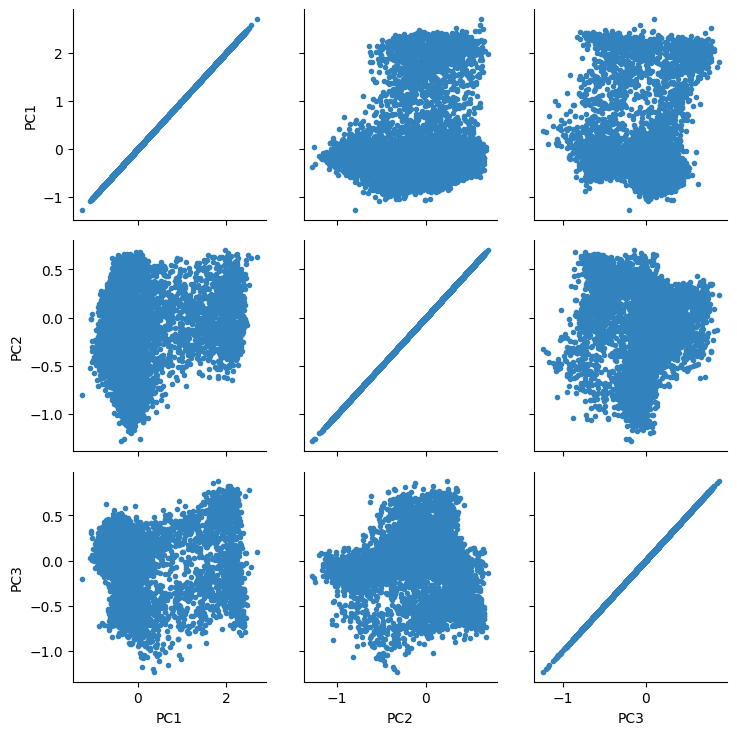

In [4]:
# Run PCA on the ensemble

# write a multistate pdb file for the whole ensemble so MDA will interpret it as a trajectory
with mda.Writer(base_directory + 'ensemble.pdb', u.atoms.n_atoms) as W:
    for structure in ensemble_df['structure']:
        u = mda.Universe(structure_directory + structure, 
                         structure_directory + structure)
        # renumber for consistency and to match selection token   s     
        u.atoms.residues.resids += resid_offset
        u.atoms.segments.segids = 'A'
        u.atoms.chainIDs = 'A'
        W.write(u.select_atoms(rmsd_selection))
 
# make a universe containing all the structures
u = mda.Universe(base_directory + "ensemble.pdb")

# align the ensemble to the selection token (and first structure)
aligner = mda.analysis.align.AlignTraj(u, u, select=rmsd_selection, in_memory=True).run()

# align the ensemble to the reference structure for umbrella sampling
#aligner = mda.analysis.align.AlignTraj(u, mda.Universe(template_pdb_for_umbrella_sampling), select=rmsd_selection + 'and chainID A', in_memory=True).run()

# center the ensemble at the origin
u.atoms.translate(-u.atoms.center_of_mass())

# write out the aligned ensemble
with mda.Writer(base_directory + 'ensemble.pdb', u.atoms.n_atoms) as W:
    for ts in u.trajectory:
        W.write(u.atoms)

# perform principal component analysis
pc = PCA(u, select=rmsd_selection, align=True, mean=None, n_components=None).run()

# project coorindates onto the principal components
pc_projection = pc.transform(u.select_atoms(rmsd_selection), n_components=n_pcs)

# divide by 10
pc_projection = pc_projection / 10


## divide each projection by the square root of the variance of the corresponding PC
#for i in range(n_pcs):
#    pc_projection[:, i] = pc_projection[:, i] / np.sqrt(pc.variance[i])
    
# sanity check - manually project min and max pc structures onto (average structure + eigenvector 1) using dot product?

# make a dataframe to store the principal component projections
pca_df = pd.DataFrame(pc_projection, columns=['PC{}'.format(i+1) for i in range(n_pcs)])
pca_df['structure'] = ensemble_df.index

# print out the PCs
display(pd.DataFrame(pca_df).head())

# show table of variances explained by each PC
display(pd.DataFrame((pc.cumulated_variance*100).round(), columns=['PC cumulated variance']).head())

#drop the structure column for plotting
pca_df_pairgrid = pca_df.drop('structure', axis=1)
g = sns.PairGrid(pca_df_pairgrid)
g.map(plt.scatter, marker='.')
plt.show()
pca_df_pairgrid = None

# add principal components to the dataframe - making sure the structures are in the same order
pca_df = pca_df.sort_values(by=['structure'])
pca_df = pca_df.reset_index(drop=True)
ensemble_df['PC1'] = pca_df['PC1'].values
ensemble_df['PC2'] = pca_df['PC2'].values
ensemble_df['PC3'] = pca_df['PC3'].values

# visualisation
n_pcs = 3
for i in range(n_pcs):
    pc_n =    pc.p_components[:, i]
    trans_n =   pc_projection[:, i]
    projected = np.outer(trans_n, pc_n) + pc.mean.flatten()
    coordinates = projected.reshape(len(trans_n), -1, 3)
    
    proj_n = mda.Merge(u.select_atoms(rmsd_selection))
    proj_n.load_new(coordinates)
    
    # write this to a multistate pdb file
    with mda.Writer(base_directory + 'pca{}.pdb'.format(i+1), proj_n.atoms.n_atoms) as W:
        for ts in proj_n.trajectory:
            W.write(proj_n.atoms)

Top pLDDT per cluster:


,structure,pDDLDT,PC1,PC2,PC3,cluster
7359,msa-64-128_rank_001.pdb,93.1,-0.659162,0.284687,0.092086,0
8185,msa-128-256_rank_207.pdb,91.2,2.103249,0.348858,-0.005547,1


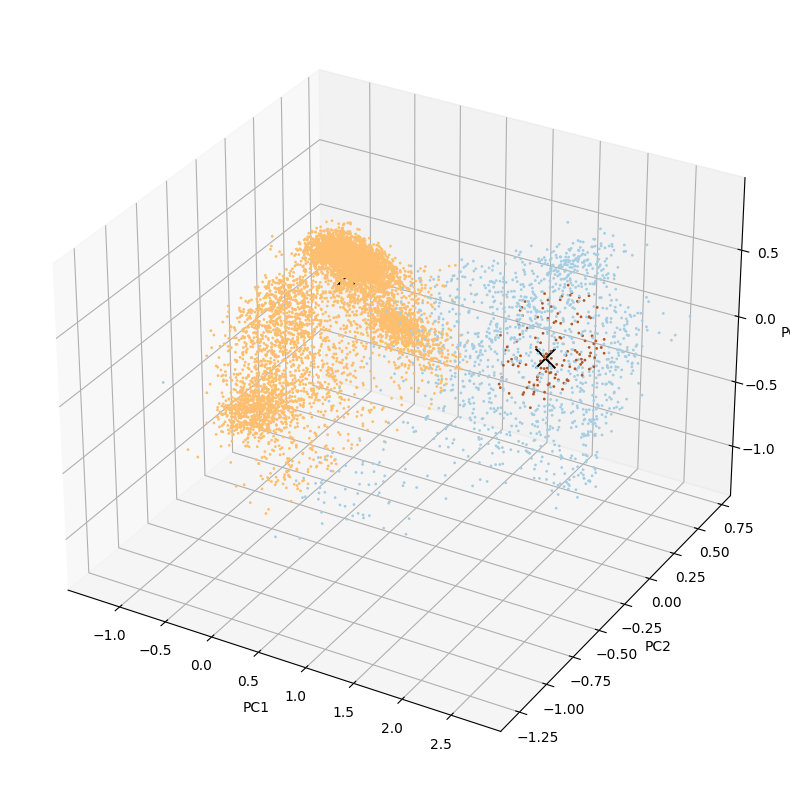

In [5]:
# Select reference structures to compare the ensemble to

from sklearn.cluster import HDBSCAN

# clustering 

# min samples is 10 percent of size of ensemble
clustering_min_samples = int(len(ensemble_df) * 0.1)

cluster = HDBSCAN(min_samples=clustering_min_samples, store_centers="medoid").fit(ensemble_df[['PC1', 'PC2', 'PC3']])

# add the cluster labels to the dataframe
ensemble_df['cluster'] = cluster.labels_

# get the number of clusters that are not noise (-1)
num_clusters = len(set(cluster.labels_)) - (1 if -1 in cluster.labels_ else 0)

cluster_representatives = []
for i in cluster.medoids_:
    # lookup the relevant structures in the dataframe (using medoid guarantees this has been sampled)
    cluster_representatives.append(ensemble_df[(ensemble_df['PC1'] == i[0]) & (ensemble_df['PC2'] == i[1]) & (ensemble_df['PC3'] == i[2])]['structure'].values[0])

cluster_best_pLDDT = []
# for each cluster number, get the structure with the highest pLDDT
for i in range(num_clusters):
    cluster_best_pLDDT.append(ensemble_df[ensemble_df['cluster'] == i].sort_values(by=['pDDLDT'], ascending=False)['structure'].values[0])

# display the best structures per cluster 
print('Top pLDDT per cluster:')
display(ensemble_df[ensemble_df['structure'].isin(cluster_best_pLDDT)].sort_values(by=['pDDLDT'], ascending=False))

# set these to the ref_structures if not using a user specified set of reference structures
if not use_reference_structures:
    ref_structures = cluster_representatives

# 3D plot of the clusters
xaxis = 'PC1'
yaxis = 'PC2'
zaxis = 'PC3'
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ensemble_df[xaxis], ensemble_df[yaxis], ensemble_df[zaxis], c=ensemble_df['cluster'], cmap='Paired', s=1, alpha=1)
for i in cluster_representatives:
    ax.scatter(ensemble_df[(ensemble_df['structure'] == i)][xaxis], ensemble_df[(ensemble_df['structure'] == i)][yaxis], ensemble_df[(ensemble_df['structure'] == i)][zaxis], c='black', marker='x', s=200)
ax.set_xlabel(xaxis)
ax.set_ylabel(yaxis)
ax.set_zlabel(zaxis)
plt.show()

In [6]:
# Populate the ensemble dataframe with properties

from ensemblr.misc_functions import get_rmsd_to_ref, get_sasa, calc_distance

# get rmsds with respect ot each of the reference structures (from PCA)
for ref_structure in ref_structures:
    rmsds = {}
    with Pool(processes=num_processes) as pool:
        rmsds = list(
            tqdm(
                pool.starmap(
                    get_rmsd_to_ref, 
                    [(structure_directory + structure, structure_directory + ref_structure, rmsd_selection) for structure in structures]
                ), 
                total=len(structures)
            )
        )
    ensemble_df['rmsd_to_' + ref_structure] = dict(rmsds).values()

sasas = {}
with Pool(processes=num_processes) as pool:
    sasas = list(tqdm(pool.imap(get_sasa, [(structure_directory + structure) for structure in structures]), total=len(structures)))
ensemble_df['sasa'] = dict(sasas).values()

if not distances_to_evaluate:
    print('No distances to evaluate')
else:
    # Iterate over the items in the dictionary
    for distance_name, (selection1, selection2) in distances_to_evaluate.items():
        distances = {}
        for structure in structures:
            distances[structure] = calc_distance(structure=structure_directory + structure, selection1=selection1, selection2=selection2, resid_offset=resid_offset)

        # add the distances to the dataframe
        ensemble_df['distance_{}'.format(distance_name)] = distances.values()

display(ensemble_df)

100%|██████████| 8317/8317 [08:19<00:00, 16.64it/s]


,structure,pDDLDT,PC1,PC2,PC3,cluster,rmsd_to_msa-64-128_rank_563.pdb,rmsd_to_msa-32-64_rank_1382.pdb,sasa,distance_TM_deflection
8,msa-8-16_rank_033.pdb,87.0,-0.140292,-1.056560,-0.120817,0,0.953707,1.624358,11149.683368,17.946732
9,msa-8-16_rank_149.pdb,85.6,-0.246438,-0.903006,-0.149196,0,0.845748,1.648779,11055.885038,18.203484
12,msa-8-16_rank_527.pdb,82.6,-0.190154,-0.011527,0.362431,0,0.690652,1.551232,11164.779324,18.301615
14,msa-8-16_rank_011.pdb,87.8,-0.197260,-0.838907,-0.150614,0,0.816374,1.613038,10936.760871,18.623890
16,msa-8-16_rank_107.pdb,86.0,-0.651387,-0.053263,0.403275,0,0.778623,1.900408,11343.462370,18.273212
...,...,...,...,...,...,...,...,...,...,...
9995,msa-128-256_rank_718.pdb,90.1,-0.415527,0.305470,0.085388,0,0.390972,1.633139,11079.477418,18.199316
9996,msa-128-256_rank_027.pdb,92.2,-0.482280,0.308210,0.177687,0,0.387305,1.686677,10860.604581,18.326365
9997,msa-128-256_rank_1416.pdb,88.7,0.074139,-0.570978,-0.149213,0,0.765584,1.418967,11410.873195,18.184422
9998,msa-128-256_rank_1806.pdb,87.6,-0.073010,0.236465,0.077724,0,0.435666,1.435548,11328.554759,18.402914


Represnetative structures from each cluster:


,structure,pDDLDT,PC1,PC2
7519,msa-64-128_rank_563.pdb,90.1,-0.433589,0.144255


,structure,pDDLDT,PC1,PC2
4023,msa-32-64_rank_1382.pdb,87.2,1.890617,-0.030322


Lowest 3 SASA:


,structure,cluster,pDDLDT,PC1,PC2
3638,msa-16-32_rank_004.pdb,0,91.1,-0.344593,-0.910612
3632,msa-16-32_rank_089.pdb,0,89.2,-0.581682,0.141016
6689,msa-64-128_rank_012.pdb,0,92.3,-0.606443,0.247451


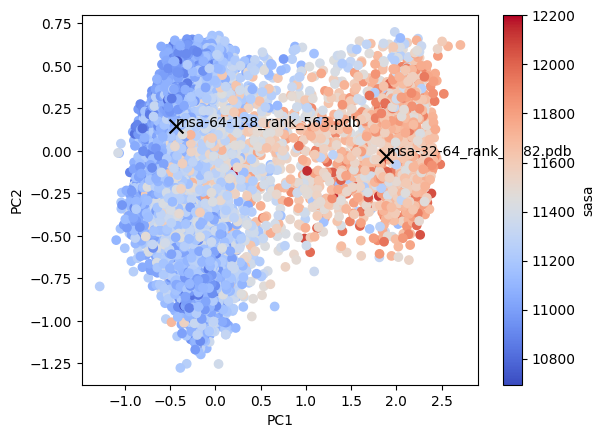

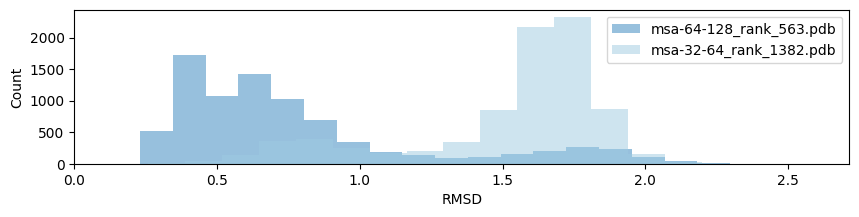

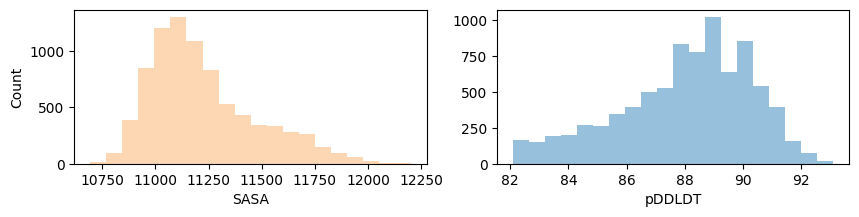

In [7]:
# Make plots of ensemble properties

# display tables of closest to reference structures, lowest sasa, and most different
print('Represnetative structures from each cluster:')
for i in ref_structures:
    display(ensemble_df.sort_values(by=['rmsd_to_' + i]).head(1)[['structure', 'pDDLDT', 'PC1', 'PC2']])
print('Lowest 3 SASA:')
display(ensemble_df.sort_values(by=['sasa']).head(3)[['structure', 'cluster', 'pDDLDT', 'PC1', 'PC2']])

# plot ensemble
plt.scatter(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], c=ensemble_df[plot_variable_3], cmap='coolwarm')
plt.xlabel(plot_variable_1)
plt.ylabel(plot_variable_2)
plt.colorbar(label=plot_variable_3)

# annotate reference structures
for i in ref_structures:
    plt.scatter(ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_1], ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_2], c='black', marker='x', s=100)
    plt.annotate(i, (ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_1], ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_2]))
plt.show()

# for each reference structure, plot the histogram of rmsd to that structure
for i in ref_structures:
    plt.hist(ensemble_df['rmsd_to_' + i], bins=20, alpha=0.5, label=i)
plt.legend(loc='upper right')
plt.xlabel('RMSD')
plt.ylabel('Count')
plt.xlim(0)
fig = plt.gcf()
fig.set_size_inches(10, 2)
plt.show()

# plot 2 pane histogram of SASA and pLDDT scores
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(ensemble_df['sasa'], bins=20, alpha=0.5, label='sasa', color='C3')
ax1.set_xlabel('SASA')
ax1.set_ylabel('Count')
ax2.hist(ensemble_df['pDDLDT'], bins=20, alpha=0.5, label='pDDLDT')
ax2.set_xlabel('pDDLDT')
fig = plt.gcf()
fig.set_size_inches(10, 2)
plt.show()


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


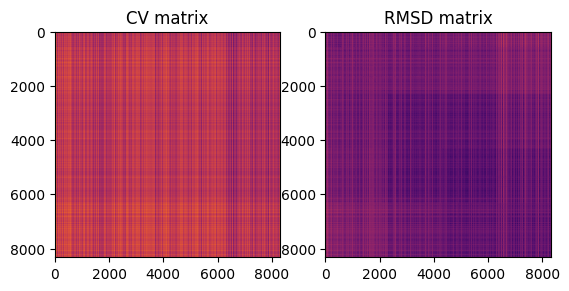

In [8]:
# Calculate property matrices (RMSD and CV) for the MC energy function

from ensemblr.calc_matrices import pdb_to_coordinates, get_rmsdmat_jax, get_diffmat

rmsd_matrix = get_rmsdmat_jax(pdb_to_coordinates(base_directory + 'ensemble.pdb'), ensemble_df)
cv_matrix = get_diffmat(ensemble_df, collective_variable)

# show for inspection
fig, axes = plt.subplots(1, 2)
matrices = [cv_matrix, rmsd_matrix]
titles = ['CV matrix', 'RMSD matrix']

for ax, matrix, title in zip(axes, matrices, titles):
    ax.imshow(matrix, cmap='inferno')
    ax.set_title(title)


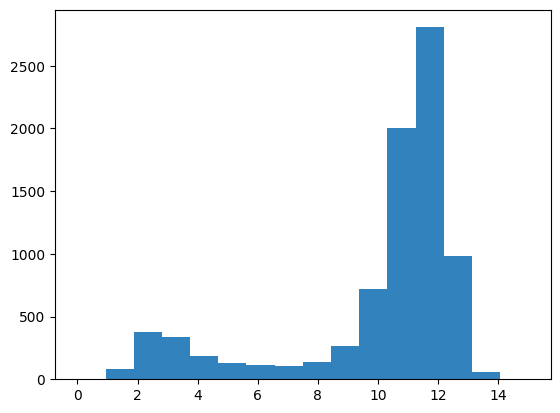

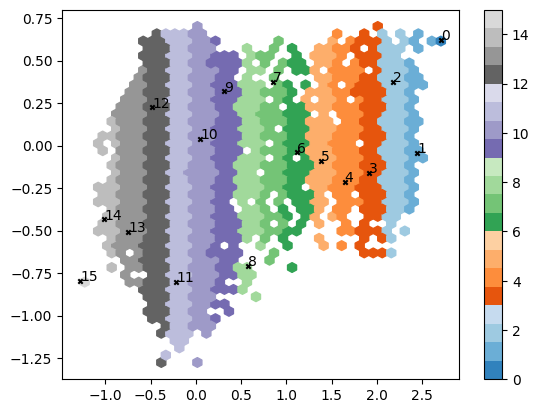

In [16]:
# Assign bins for the MC path optimisation

use_defined_end_states = False

occluded_state = 'msa-64-128_rank_1142.pdb'
#lumen_open 'msa-128-256_rank_1163.pdb'
#cyto open 'msa-32-64_rank_127.pdb'

# end states to interpolate between values of the CV of
end_state_1 = 'msa-32-64_rank_1297.pdb' #'msa-32-64_rank_127.pdb' #'' #msa-128-256_rank_1163.pdb
end_state_2 = occluded_state

if use_defined_end_states == True:
    max_value = end_state_1_cv_value
    min_value = end_state_2_cv_value

    # get the values of the CV for these structures
    end_state_1_cv_value = ensemble_df[ensemble_df['structure'] == end_state_1][collective_variable].values[0]
    end_state_2_cv_value = ensemble_df[ensemble_df['structure'] == end_state_2][collective_variable].values[0]

else:
    # just get the min and max value of the end states globally, like before
    max_value = ensemble_df[collective_variable].max()
    min_value = ensemble_df[collective_variable].min()


## get the ideal collective variable values per window between min and max_value using linear interpolation
ideal_window_values = np.zeros(mc_n_bins)
for i in range(mc_n_bins):
    ideal_window_values[i] = np.interp(i, [0, mc_n_bins-1], [max_value, min_value])
ideal_initial_path = []
for i in ideal_window_values:
    ideal_initial_path.append(ensemble_df[collective_variable].sub(i).abs().idxmin())

# replace the first and last structures in the ideal path with the end states
if use_defined_end_states == True:
    ideal_initial_path[0] = ensemble_df[ensemble_df['structure'] == end_state_1].index[0]
    ideal_initial_path[-1] = ensemble_df[ensemble_df['structure'] == end_state_2].index[0]

## set up the bins for the binned path
ensemble_df['closest_ideal_structure'] = ensemble_df[collective_variable].apply(lambda x: ideal_initial_path[np.argmin(np.abs(ideal_window_values - x))])
ensemble_df['bin'] = ensemble_df['closest_ideal_structure'].apply(lambda x: ideal_initial_path.index(x))


# plotting
#display(ensemble_df)
plt.hist(ensemble_df['bin'], bins=mc_n_bins)
plt.show()

# show bin distribution
plt.hexbin(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], C=ensemble_df['bin'], cmap='tab20c', gridsize=40, reduce_C_function=np.amax)
#plt.scatter(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], c=ensemble_df['bin'], cmap='tab20c')
plt.colorbar()

# plot the initial guesses
for i in range(mc_n_bins):
    plt.scatter(ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_1], ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_2], marker='x', color='black', s=10)
# label the ideal structures wit htheir associated bin
for i in range(mc_n_bins):
    plt.annotate(i, (ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_1], ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_2]))

plt.show()

100%|██████████| 100/100 [00:00<00:00, 986895.06it/s]


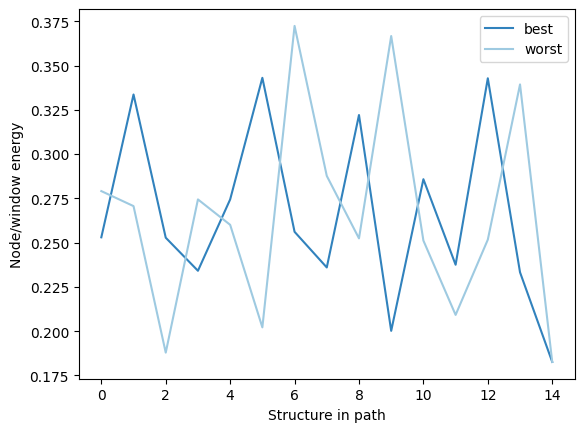

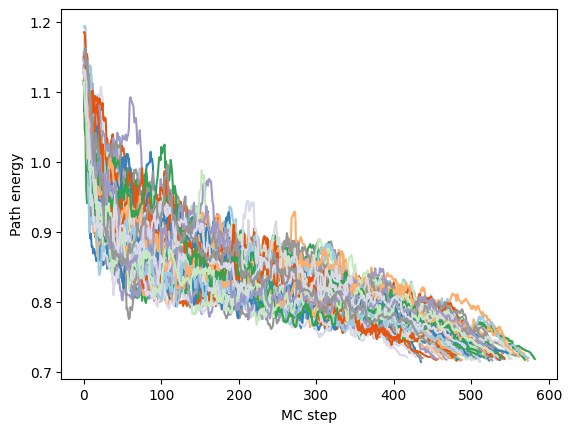

In [17]:
# MC path optimisation, uses Pool for parallel execution

from ensemblr.monte_carlo import mc_path_optimisation

# settings
reproducible_seeds = True
mc_n_runs = 100

# run the monte carlo path optimisation
if reproducible_seeds:
    seeds = range(mc_n_runs)
else:
    seeds = np.random.randint(low=0, high=1e3, size=mc_n_runs)
with Pool(processes=num_processes) as pool:
    mc_runs = list(
        tqdm(
            pool.starmap(
                # positional arguments passed as a tuple
                mc_path_optimisation,
                zip(
                    seeds, 
                    [ideal_initial_path]*mc_n_runs, 
                    [rmsd_matrix]*mc_n_runs, 
                    [cv_matrix]*mc_n_runs, 
                    [ensemble_df]*mc_n_runs,
                    'False'*mc_n_runs
                )
            ), 
            total=mc_n_runs
        )
    )
mc_runs_df = pd.DataFrame(mc_runs, columns=['energy', 'path', 'path structures', 'relaxation energies']).sort_values(by=['energy'])

# plotting below
def lookup_and_plot_energy_per_structure(mc_df, index, label, wf_rmsd=1, wf_cv=1): # Be warned this only uses the same energy function path optimisation if you set wf_rmsd and wf_cv correctly
    energy = {}
    path = mc_df.iloc[index]['path']
    for i in range(mc_n_bins - 1):
        energy[i] = wf_rmsd * np.sqrt(rmsd_matrix[np.where(ensemble_df.index.values == path[i])[0][0], np.where(ensemble_df.index.values == path[i+1])[0][0]]**2)
        energy[i] = wf_cv * np.sqrt(cv_matrix[np.where(ensemble_df.index.values == path[i])[0][0], np.where(ensemble_df.index.values == path[i+1])[0][0]]**2)
    plt.plot(energy.values(), label=label)
    plt.xlabel('Structure in path')
    plt.ylabel('Node/window energy')
    plt.legend()

lookup_and_plot_energy_per_structure(mc_runs_df, 0, 'best')
lookup_and_plot_energy_per_structure(mc_runs_df, -1, 'worst')
plt.show()
for i in range(1, mc_n_runs):
    plt.plot(mc_runs_df.iloc[i]['relaxation energies'])
plt.xlabel('MC step')
plt.ylabel('Path energy')
plt.show()

# write out the best run to a multistate pdb file for visualisation
with mda.Writer(base_directory + 'best_run.pdb', u.atoms.n_atoms) as W:
    # head gets the structures of the lowest energy path because the dataframe is sorted by energy above
    for structure in mc_runs_df.head(1)['path structures'].values[0]:   
        if structure == 'ref_outward.pdb' or structure == 'ref_inward.pdb':
            # useful if the reference structures have different metadata labelling (e.g. if they came from a pdb)
            u.atoms.segments.segids = 'A'
            u.atoms.chainIDs = 'A'
        u = mda.Universe(structure_directory + structure, structure_directory + structure)
        u.atoms.residues.resids += resid_offset
        W.write(u.select_atoms('protein'))


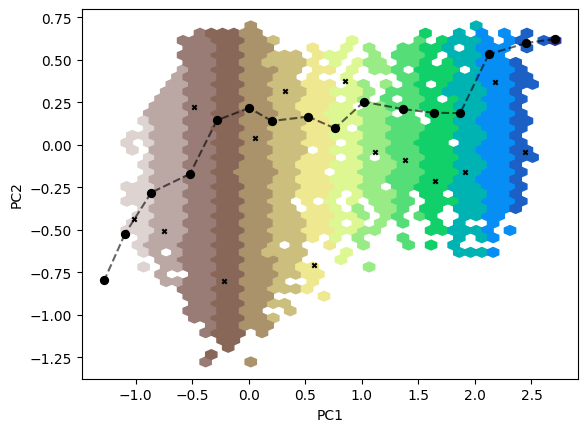

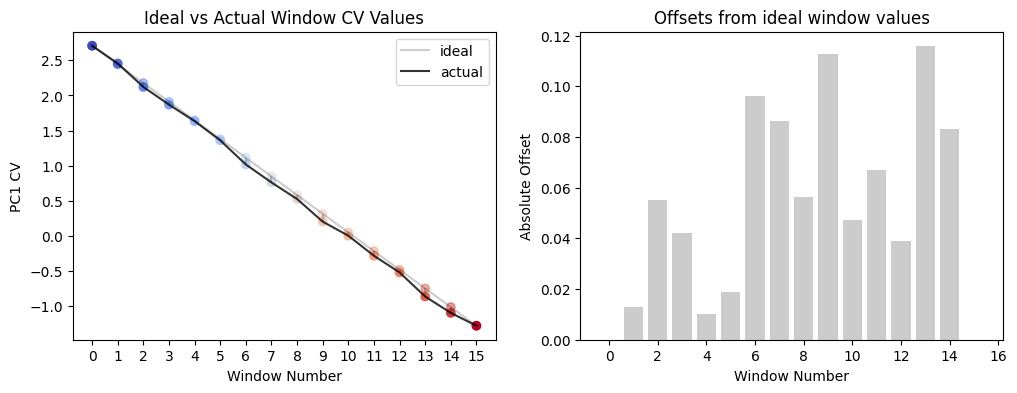

Actual vs ideal window values:


,ideal,actual
0,2.708865,2.708865
1,2.443024,2.455846
2,2.177184,2.122176
3,1.911344,1.869377
4,1.645503,1.635252
5,1.379663,1.360841
6,1.113823,1.017748
7,0.847982,0.761621
8,0.582142,0.525621
9,0.316302,0.203529


In [18]:
# Plot and assess the optimal path
plt.hexbin(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], C=ensemble_df['bin'], cmap='terrain', gridsize=40, reduce_C_function=np.amax)
for structure in mc_runs_df.head(1)['path'].values[0]:
    plt.scatter(ensemble_df.loc[structure][plot_variable_1], ensemble_df.loc[structure][plot_variable_2], c='black', s=32)
# draw connecting lines
for i in range(len(mc_runs_df.head(1)['path'].values[0]) - 1):
    x1 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i]][plot_variable_1]
    y1 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i]][plot_variable_2]
    x2 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i+1]][plot_variable_1]
    y2 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i+1]][plot_variable_2]
    plt.plot([x1, x2], [y1, y2], c='black', alpha=0.6, linestyle='dashed')
# plot the initial guesses
for i in range(mc_n_bins):
    plt.scatter(ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_1], ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_2], marker='x', color='black', s=10)

plt.xlabel(plot_variable_1)
plt.ylabel(plot_variable_2)
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

# Umbrella sampling quality control plots
axs[0].plot(ideal_window_values, label='ideal', color='black', alpha=0.2)
axs[0].scatter(range(mc_n_bins), ideal_window_values, c=range(mc_n_bins), cmap='coolwarm', alpha=0.5)
actual_window_values = np.zeros(mc_n_bins)
for i in range(mc_n_bins):
    actual_window_values[i] = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i]][collective_variable]
axs[0].plot(actual_window_values, label='actual', c='black', alpha=0.8)
axs[0].scatter(range(mc_n_bins), actual_window_values, c=range(mc_n_bins), cmap='coolwarm')
for i in range(mc_n_bins):
    axs[0].plot([i, i], [ideal_window_values[i], actual_window_values[i]], c='black', alpha=0.2, linestyle='dashed')
axs[0].set_xticks(range(mc_n_bins))
axs[0].set_xlabel('Window Number')
axs[0].set_ylabel(collective_variable + ' CV')
axs[0].legend()
axs[0].set_title('Ideal vs Actual Window CV Values')
offsets = np.abs(ideal_window_values - actual_window_values)
axs[1].bar(range(mc_n_bins), offsets, color='black', alpha=0.2)
axs[1].set_xlabel('Window Number')
axs[1].set_ylabel('Absolute Offset')
axs[1].set_title('Offsets from ideal window values')
plt.show()

# display actual vs idea in table
print('Actual vs ideal window values:')
window_values = pd.DataFrame({'ideal': ideal_window_values, 'actual': actual_window_values})
display(window_values)


In [19]:
# Set up umbrella sampling windows from the optimal path

#import importlib
from MDAnalysis.analysis import align, rms
import shutil
from ensemblr.us_window_setup import align_universe, protein_coordinate_replacer, write_pca_ref_pdb, plumed_input_writer, fix_overlapping_atoms#, write_pca_ref_pdb_typeoptimal

# template handling 
u_template = mda.Universe(template_pdb_for_umbrella_sampling, template_pdb_for_umbrella_sampling)
umbrella_sampling_directory = base_directory + 'umbrella_sampling/'

# get average coords for mda PC calculation
u_average = mda.Universe(base_directory + 'ensemble.pdb')
u_average.trajectory[0]
u_average.select_atoms('all').positions = pc.mean
u_average.atoms.write(base_directory + 'average_structure.pdb')

# align template to average structure
#align_universe(u_template, u_average, rmsd_selection + ' and chainID A')

## US window handler
window_directories = [] # prepare directories for each window
for i in range(mc_n_bins):
    window_directories.append(umbrella_sampling_directory + 'window_' + str(i))
    if not os.path.exists(window_directories[i]):
        os.makedirs(window_directories[i])
    shutil.copy(structure_directory + mc_runs_df.head(1)['path structures'].values[0][i], window_directories[i])    # copy the relevant structure in mc_runs_df to the window directory

# for each window, replace the coordinates of the protein in the template universe with the coordinates of the structure at the corresponding index in the best path
for i in range(mc_n_bins):
    u = u_template.copy()   
    structure = mc_runs_df.head(1)['path structures'].values[0][i] # make a universe out of the structure corresponding to the index in the best path
    u_structure = mda.Universe(structure_directory + structure, structure_directory + structure)
    u_structure = align_universe(u_structure, u, rmsd_selection + ' and chainID A') # align the structures to the template universe

    # replace the coordinates of the protein in the template universe with the coordinates of the structure at the corresponding index in the best path
    protein_coordinate_replacer(u_structure, u, resid_offset=resid_offset, selection_token='protein and chainID A')
    fix_overlapping_atoms(u) # resolve clashes

    # write out the universe to a pdb file
    u.atoms.write(window_directories[i] + '/window_' + str(i) + '.pdb')

#######################

def write_pca_ref_pdb_typeoptimal(u_structure, u_template, eigenvector, pca_selection_token, output_file='pca_ref.pdb'):#pca_reference='pca1.pdb', output_file='pca_ref.pdb'):

    """
    Wries a template PDB file for use in the PLUMED script. 

    Parameters
    ----------
    Some

    Returns
    -------
    None 
        
    """

    list_of_atom_ids_in_template = []

    # loop though atoms matchign the selection in the template universe and get their ids (not their indices) and make these into a list
    for atom in u_template.select_atoms(pca_selection_token).atoms:
        list_of_atom_ids_in_template.append(atom.id)

    # print the length of the list
    print('Number of atoms in the template universe: ', len(list_of_atom_ids_in_template))
    #  check that this matches the length of the selection in the structure (ensemble) universe
    print('Number of atoms in the ensemble universe: ', len(u_structure.select_atoms(pca_selection_token).atoms))

    # if these dont match print an error
    if len(list_of_atom_ids_in_template) != len(u_structure.select_atoms(pca_selection_token).atoms):
        print('ERROR: Number of atoms in the template universe does not match the number of atoms in the ensemble universe\n so theres no guarantee the IDs correspond to the same atoms\n')

    # write out the selection matching pca_selection_token while PRESERVING ATOM IDS from the template (i.e. not renumbered)
    # this is important because the atom IDs in the PCA reference file must match those in the template

    pca_selection = u_structure.select_atoms(pca_selection_token)

    with open(output_file, 'w') as f:
        i = 0
        f.write('REMARK TYPE=OPTIMAL\n')
        for atom in pca_selection.atoms:
            f.write('ATOM  %5d %4s %3s %5d    %8.3f%8.3f%8.3f  1.00  1.00           %2s\n' % (list_of_atom_ids_in_template[i], atom.name, atom.resname, atom.resid, atom.position[0], atom.position[1], atom.position[2], atom.element))
            i += 1
        f.write('END\nREMARK TYPE=OPTIMAL\n')

    # now add the eigenvector to the file
    with open(output_file, 'a') as f:
        i = 0
        for atom in pca_selection.atoms:
            f.write('ATOM  %5d %4s %3s %5d    %8.3f%8.3f%8.3f  1.00  0.00           %2s\n' % (list_of_atom_ids_in_template[i], atom.name, atom.resname, atom.resid, eigenvector[i,0], eigenvector[i,1], eigenvector[i,2], atom.element))
            i += 1
        f.write('END\n')

    # write a multistate pdb file interpolating along the eigenvector to visualise the direction
    with mda.Writer(output_file.replace('.pdb', '_interpolated_2.pdb'), pca_selection.atoms.n_atoms) as W:
        for i in range(0, 2, 1):
            pca_selection.atoms.positions = pca_selection.atoms.positions + (i * 100*eigenvector)
            W.write(pca_selection.atoms)

##################

## plumed CV handler
print('collective variable is:', collective_variable, '\n')

# if cv is a label in the distances to evaluate dictionary
if collective_variable in distances_to_evaluate.keys():

    pcavar = False

    com1 = distances_to_evaluate[collective_variable][0]
    com2 = distances_to_evaluate[collective_variable][1]

    # write out the plumed file
    plumed_input_writer(ideal_window_values, umbrella_sampling_directory + '/plumed.dat', molinfo_pdb=template_pdb_for_umbrella_sampling, COM_1=com1, COM_2=com2)

# condition for PCA based CV
elif collective_variable == 'PC1':

    pcavar = True

    # get the eigenvector from the MDA pca object
    eigenvector = pc.p_components[:, 0].reshape(-1,3) # first principal component, features reshaped to get cartesian components

    # dummy universe with two frames, one for the average structure and one for the average structure + eigenvector
    u_average_plus_eig = mda.Universe(base_directory + 'average_structure.pdb')
    u_average_plus_eig.select_atoms('all').positions = pc.mean + eigenvector

    # write out a plumed reference file for the linear subspace projection
    write_pca_ref_pdb(u_structure=u_average, u_template=u, eigenvector=eigenvector, pca_selection_token=rmsd_selection + 'and chainID A', output_file=umbrella_sampling_directory + 'pca_ref.pdb')

    write_pca_ref_pdb_typeoptimal(u_structure=u_average, u_template=u, eigenvector=eigenvector, pca_selection_token=rmsd_selection + 'and chainID A', output_file=umbrella_sampling_directory + 'pca_ref_typeoptimal.pdb')

    # write out the plumed file
    plumed_input_writer(ideal_window_values, umbrella_sampling_directory + '/plumed.dat', cv_reference_pdb=umbrella_sampling_directory + 'pca_ref.pdb', molinfo_pdb=template_pdb_for_umbrella_sampling)

else:
    print('Unknown collective variable. Writing generic plumed file')
    com1 = '{your atoms here}'
    com2 = '{your atoms here}'
    pcavar = False


collective variable is: PC1 

Number of atoms in the template universe:  219
Number of atoms in the ensemble universe:  219
Number of atoms in the template universe:  219
Number of atoms in the ensemble universe:  219


['/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_0/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_1/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_10/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_11/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_12/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_13/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_14/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_15/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_2/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_3/COLVAR_MULTI', '/biggin/b212/bioc1781/Projects/KDELR/red-msa/umbrella_sampling/window_4/COLVAR_MULTI', '/biggin/b212/bioc1781/Pr

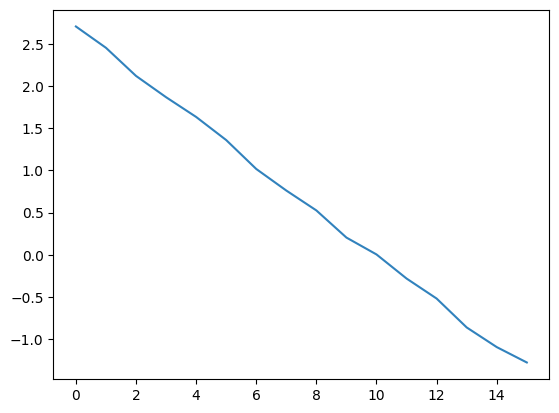

cv ratios: [ 4.55198070e-02  4.55028459e-02  2.30423896e-04 -6.70704681e-03
 -1.42779219e-02 -2.87043124e-02 -4.89404129e-02 -7.63214062e-02
  1.83601771e-01  4.21119092e-01  2.24091108e+01 -2.21271640e-01
 -9.01013902e-02 -4.06638351e-02 -2.22481032e-02 -7.51833485e-03]


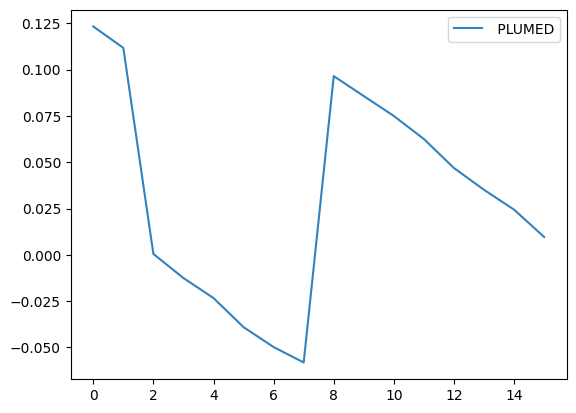

In [23]:
# read the COLVAR_MULTI files using glob
import glob
colvar_files = glob.glob(umbrella_sampling_directory + 'window_*/COLVAR_MULTI')
# sort by window
colvar_files.sort()
print(colvar_files)

# read second column second line to get CV value from plumed
cv_values = []
for file in colvar_files:
    with open(file, 'r') as f:
        lines = f.readlines()
        cv_values.append(float(lines[1].split()[1]))

# plot the CV values
#plt.plot(cv_values, label='PLUMED')

# plot actual vs ideal
plt.plot(actual_window_values, label='MDA')

plt.show()

# get ratio of plumed to mda
cv_ratios = np.array(cv_values) / np.array(actual_window_values)
print('cv ratios:', cv_ratios)

# scale the plumed CV values to match the MDA CV values
scaled_cv_values = np.array(cv_values) / cv_ratios.mean()

plt.plot(cv_values, label=' PLUMED')


plt.legend()
plt.show()